# 세종시 불법 주정차 및 공영 주차장 심층 분석

본 노트북은 세종시의 지역별 불법 주정차 단속 데이터와 공영 주차장 공간 데이터를 교차 분석하여 주차 인프라 공급과 단속 간의 상관성을 정밀하게 분석합니다.

### 주요 분석 내용:
1. **Outer Join 결합 분석**: 공영 주차장이 아예 없는 17개 행정동을 포함하여 전체 29개 지역의 전수 비교 분석
2. **통계적 상관성 검정**: 주차 공급량(구획수)과 단속 건수 간의 Pearson 및 Spearman 상관 분석
3. **시간대별 단속 패턴 시각화**: 24시간대별 지역 단속 현황 히트맵 도출
4. **지역 유형별 시간 프로파일 분석**: 나성동(상업), 어진동(행정), 고운동(학원/주거), 조치원읍(전통) 간 단속 흐름 비교
5. **단속 수단 및 주차장 요금제(유료화 비율) 분석**: 주민 민감도(안전신문고) 및 요금 회피 가능성 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from matplotlib import font_manager, rc
from pathlib import Path

# 한글 폰트 설정 (macOS 및 Windows 호환)
font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_path = Path('C:/Windows/Fonts/malgun.ttf')

if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    rc('font', family=font_manager.FontProperties(fname=str(font_path)).get_name())
else:
    for font_name in font_candidates:
        if font_name in available_fonts:
            rc('font', family=font_name)
            break

plt.rcParams['axes.unicode_minus'] = False

# 데이터 경로 정의
illegal_raw_path = '../data/raw/세종특별자치시_불법주정차 단속현황_20250731.csv'
parking_raw_path = '../data/raw/세종특별자치시_주차장정보.csv'
illegal_summary_path = '../data/processed/illegal_summary.csv'
parking_summary_path = '../data/processed/parking_summary.csv'

print("라이브러리 및 폰트 로드 완료.")

라이브러리 및 폰트 로드 완료.


## 1. 데이터 로드 및 지역 분류 전처리

단속 위치 텍스트 키워드를 통해 읍/면/동 행정구역명을 재분류합니다.

In [2]:
illegal_raw = pd.read_csv(illegal_raw_path)
parking_raw = pd.read_csv(parking_raw_path, encoding='CP949')
illegal_summary = pd.read_csv(illegal_summary_path)
parking_summary = pd.read_csv(parking_summary_path)

region_map = {
    '한솔': '한솔동', '새롬': '새롬동', '나성': '나성동', '다정': '다정동', '도담': '도담동',
    '어진': '어진동', '해밀': '해밀동', '아름': '아름동', '종촌': '종촌동', '고운': '고운동',
    '보람': '보람동', '대평': '대평동', '소담': '소담동', '반곡': '반곡동', '가람': '가람동',
    '용포외곽길':'금남면', '세종시립도서관':'고운동', '세종교육청':'보람동', '새샘':'소담동',
    '새솔유치원':'다정동', '해들':'대평동', '범지기':'아름동', '새뜸':'새롬동', '가온':'다정동',
    '보건복지부':'어진동', '코스트코':'대평동', '국민은행첫마을지점':'나성동', '축산물품질평가원':'아름동',
    '국민권익위원회':'어진동', '호려울마을4단지':'보람동', '명동초':'조치원읍', '대영프라자':'아름동',
    '가재마을5단지':'종촌동', '대수약국':'조치원읍', '에반아트리움':'나성동', '어반아트리움':'나성동',
    '보건환경연구원':'조치원읍', '수루배마을':'반곡동', '호려울마을':'보람동', '나릿재':'나성동',
    '행정안전부':'어진동', '첫마을':'한솔동', '새나루':'집현동', '도시통합정보센터':'조치원읍',
    '삼일아파트':'조치원읍', '도램마을':'도담동', '센트럴타워':'나성동', '원리119':'조치원읍',
    '국무총리':'어진동', '한결초':'다정동', '온빛초':'고운동', '농림축산식품부':'어진동',
    '정부청사':'어진동', '양지':'도담동', '가재':'종촌동', '두루':'고운동', '봉암자율방범대':'연서면',
    '늘봄초등학교':'도담동', '여울초':'보람동', '한뜰마을':'어진동', '가락마을':'고운동',
    '성프란치스코성당':'고운동', '마크원에비뉴':'나성동', '연남초':'연기면', '도원초':'연서면',
    '가락유치원':'고운동', '백두산빌딩':'종촌동', '국세청':'나성동', '교동초':'조치원읍',
    '나래초':'아름동', '참샘유치원':'한솔동', '금강프라자':'나성동', '산업통상자원부':'어진동',
    '신봉초등학교':'조치원읍', '엠브릿지사거리':'어진동', '명학리 978':'연동면', '치원읍':'조치원읍',
    '명학산단로':'연동면', '명학산단서로':'연동면', '명학산단남로':'연동면', '명학산단1로':'연동면',
    '원합강1길':'연동면', '발산1길':'금남면', '용포중앙2길':'금남면', '퇴미로':'부강면', '부촌길':'부강면',
    '산울': '산울동', '집현': '집현동', '세종': '세종동', '한별': '한별동', '조치원': '조치원읍',
    '연기': '연기면', '연동': '연동면', '부강': '부강면', '금남': '금남면', '장군': '장군면',
    '연서': '연서면', '전의': '전의면', '전동': '전동면', '소정': '소정면'
}

def classify_region(place):
    place = str(place)
    for keyword, region in region_map.items():
        if keyword in place:
            return region
    return '미분류'

illegal_raw['지역'] = illegal_raw['단속장소'].apply(classify_region)
illegal_raw = illegal_raw[illegal_raw['지역'] != '미분류']
print(f"분류 및 정제 후 단속 데이터 수: {len(illegal_raw):,}행")

분류 및 정제 후 단속 데이터 수: 126,303행


## 2. Outer Join 데이터 결합 및 주차장 유무 그룹 비교

공영 주차장이 아예 존재하지 않아 이전 분석에서 누락되었던 **17개 행정구역**을 포함한 전체 29개 구역의 결합 통계를 산출합니다.

In [3]:
# Outer Join 적용 및 결측치 0 채우기
full_df = pd.merge(illegal_summary, parking_summary, on='지역', how='left')
full_df['주차장수'] = full_df['주차장수'].fillna(0).astype(int)
full_df['주차구획수'] = full_df['주차구획수'].fillna(0).astype(int)

# 1면당 단속건수 및 면적당 구획수 생성
full_df['주차구획 1면당 단속건수'] = np.where(
    full_df['주차구획수'] > 0,
    (full_df['단속건수'] / full_df['주차구획수']).round(2),
    np.nan
)
full_df['면적당 주차구획수'] = (full_df['주차구획수'] / full_df['면적']).round(2)

display(full_df.head(15))

# 주차장 보유 유무에 따른 단속 빈도 비교
has_parking = full_df[full_df['주차구획수'] > 0]
no_parking = full_df[full_df['주차구획수'] == 0]

print("\n--- 주차장 유무 그룹 비교 ---")
print(f"공영 주차장 보유 지역 (N={len(has_parking)}): 평균 단속건수 = {has_parking['단속건수'].mean():.1f}건, 평균 밀도 = {has_parking['면적 당 단속건수'].mean():.1f}건/km2")
print(f"공영 주차장 미보유 지역 (N={len(no_parking)}): 평균 단속건수 = {no_parking['단속건수'].mean():.1f}건, 평균 밀도 = {no_parking['면적 당 단속건수'].mean():.1f}건/km2")

,지역,단속건수,면적,면적 당 단속건수,주차장수,주차구획수,주차구획 1면당 단속건수,면적당 주차구획수
0,새롬동,7922,1.49,5317,0,0,NaN,0.00
1,다정동,8908,1.70,5240,0,0,NaN,0.00
2,아름동,10572,2.19,4827,1,236,44.80,107.76
3,어진동,11016,2.65,4157,0,0,NaN,0.00
4,고운동,15164,5.35,2834,0,0,NaN,0.00
5,대평동,4065,1.50,2710,0,0,NaN,0.00
6,소담동,3086,1.17,2638,1,51,60.51,43.59
7,보람동,3352,1.33,2520,4,238,14.08,178.95
8,도담동,4480,2.03,2207,1,13,344.62,6.40
9,조치원읍,28321,13.56,2089,38,1299,21.80,95.80



--- 주차장 유무 그룹 비교 ---
공영 주차장 보유 지역 (N=12): 평균 단속건수 = 5533.1건, 평균 밀도 = 1413.2건/km2
공영 주차장 미보유 지역 (N=17): 평균 단속건수 = 3523.9건, 평균 밀도 = 1266.1건/km2


## 3. 통계적 상관관계 분석

주차 공급 공간의 총 규모와 불법 주정차 단속 건수의 연관성을 피어슨(Pearson) 및 스피어먼(Spearman) 상관계수를 사용해 검정합니다.

In [4]:
# 총량 상관분석
pearson_val, pearson_p = stats.pearsonr(full_df['주차구획수'], full_df['단속건수'])
spearman_val, spearman_p = stats.spearmanr(full_df['주차구획수'], full_df['단속건수'])

print("[총 공급량 vs 총 단속건수 상관분석]")
print(f"  Pearson 상관계수: {pearson_val:.4f} (p-value: {pearson_p:.4e})")
print(f"  Spearman 상관계수: {spearman_val:.4f} (p-value: {spearman_p:.4e})")

# 밀도 상관분석
pearson_val_dens, pearson_p_dens = stats.pearsonr(full_df['면적당 주차구획수'], full_df['면적 당 단속건수'])
print(f"\n[공급 밀도 vs 단속 밀도 상관분석]")
print(f"  Pearson 상관계수: {pearson_val_dens:.4f} (p-value: {pearson_p_dens:.4e})")

[총 공급량 vs 총 단속건수 상관분석]
  Pearson 상관계수: 0.7289 (p-value: 7.3245e-06)
  Spearman 상관계수: 0.2811 (p-value: 1.3969e-01)

[공급 밀도 vs 단속 밀도 상관분석]
  Pearson 상관계수: 0.2953 (p-value: 1.1990e-01)


## 4. 시간대별 단속 패턴 및 지역별 교차 분석 (히트맵)

전체 단속 건수 상위 15개 지역의 24시간 단속 빈도를 히트맵으로 시각화하여 단속 피크 시간대를 직관적으로 확인합니다.

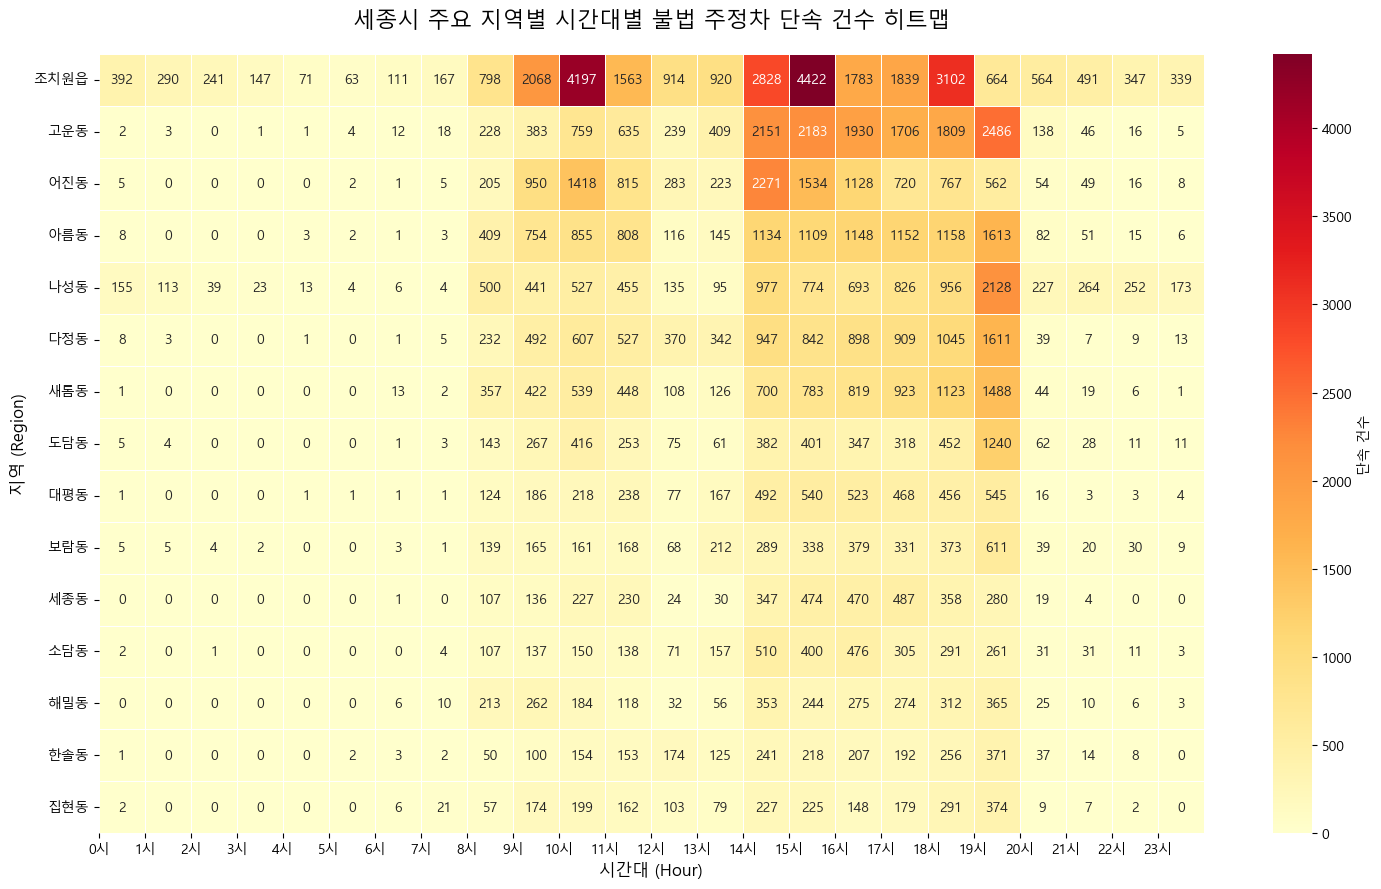

In [5]:
illegal_raw['Hour'] = pd.to_datetime(illegal_raw['단속시간'], format='%H:%M:%S', errors='coerce').dt.hour

pivot_df = pd.pivot_table(
    illegal_raw,
    index='지역',
    columns='Hour',
    values='연번',
    aggfunc='count',
    fill_value=0
)
pivot_df['Total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='Total', ascending=False)
pivot_df_clean = pivot_df.drop(columns='Total')

# 상위 15개 지역 추출하여 히트맵 플로팅
top_15_regions = pivot_df_clean.head(15)

plt.figure(figsize=(15, 9))
sns.heatmap(top_15_regions, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': '단속 건수'}, linewidths=0.5)
plt.title('세종시 주요 지역별 시간대별 불법 주정차 단속 건수 히트맵', fontsize=16, pad=20)
plt.xlabel('시간대 (Hour)', fontsize=12)
plt.ylabel('지역 (Region)', fontsize=12)
plt.xticks(range(24), labels=[f"{h}시" for h in range(24)])
plt.tight_layout()
plt.show()

## 5. 지역 교통 유형별 단속 시간 프로파일 비교

도시계획적 성격이 다른 4개 주요 지역(조치원읍, 어진동, 나성동, 고운동)의 단속 집중 비율(%) 시간 흐름도를 비교합니다.

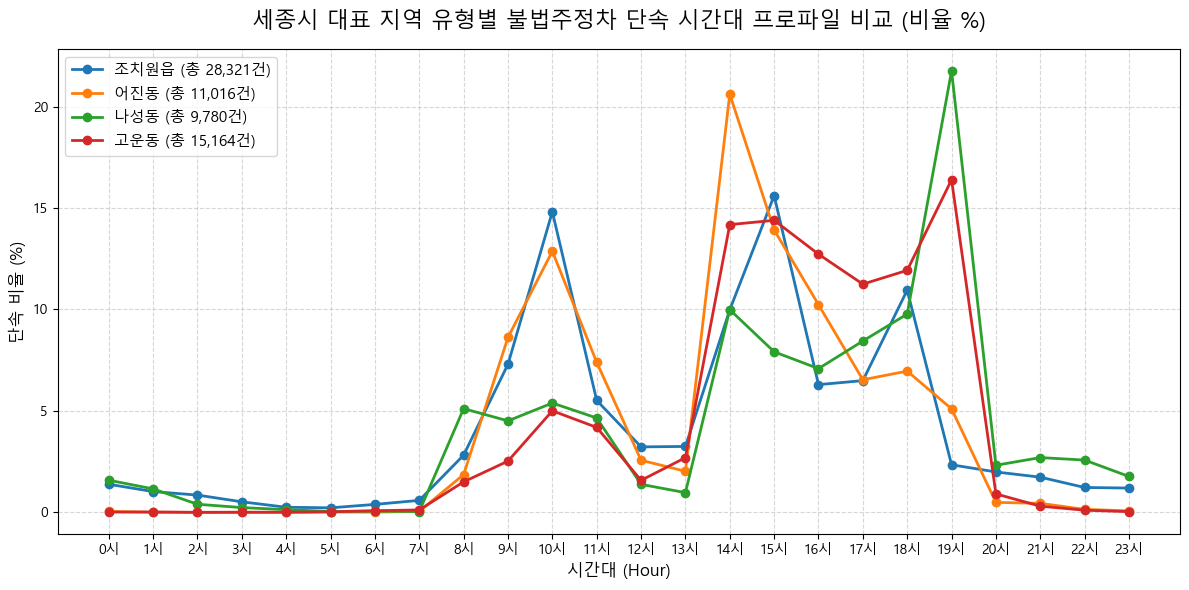

In [6]:
key_regions = ['조치원읍', '어진동', '나성동', '고운동']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(12, 6))
for region, color in zip(key_regions, colors):
    profile = pivot_df_clean.loc[region]
    profile_pct = (profile / profile.sum()) * 100
    plt.plot(
        profile_pct.index,
        profile_pct.values,
        marker='o',
        linewidth=2,
        color=color,
        label=f"{region} (총 {int(profile.sum()):,}건)"
    )

plt.title('세종시 대표 지역 유형별 불법주정차 단속 시간대 프로파일 비교 (비율 %)', fontsize=16, pad=15)
plt.xlabel('시간대 (Hour)', fontsize=12)
plt.ylabel('단속 비율 (%)', fontsize=12)
plt.xticks(range(24), labels=[f"{h}시" for h in range(24)])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 6. 주민 신고(안전신문고) 비율 및 주차장 유료 요금제 영향 분석

주민들의 단속 신고가 활발한 민감 지역을 안전신문고 비율로 추출하고, 유료 공영주차장 공급 성격과의 결합을 통해 추가적인 시사점을 도출합니다.

In [8]:
# 지역별 단속 방식 비율 집계
method_by_region = pd.crosstab(illegal_raw['지역'], illegal_raw['단속구분'], normalize='index') * 100
method_by_region['Total'] = illegal_raw['지역'].value_counts()
print("--- 지역별 단속 방식 비중 (%) ---")
display(method_by_region.sort_values(by='Total', ascending=False).head(10))

# 주차장 위치 지역 매핑 및 유무료 공간 분류
import geopandas as gpd
from shapely.geometry import Point

parking_raw['geometry'] = parking_raw.apply(
    lambda x: Point(x['주차장 위치 경도 좌표정보'], x['주차장 위치 위도 좌표정보']),
    axis=1
)
geo_pk = gpd.GeoDataFrame(parking_raw, geometry='geometry', crs='EPSG:4326')
geo_shp = gpd.read_file('../data/sejong-geodata/bnd_dong.shp', encoding='utf-8')
geo_shp = geo_shp.set_crs(epsg=5179, allow_override=True).to_crs(epsg=4326)
pk_with_region = gpd.sjoin(geo_pk, geo_shp, how='left', predicate='within')

print("\n--- 지역별 무료 vs 유료 주차면 공급수 ---")
pk_fee_summary = pd.crosstab(
    pk_with_region['ADM_NM'],
    pk_with_region['주차장 요금 유무 정보'],
    values=pk_with_region['주차장 주차 구획수'],
    aggfunc='sum'
).fillna(0).astype(int)
display(pk_fee_summary)

--- 지역별 단속 방식 비중 (%) ---


단속구분,고정형CCTV,국민신문고,민원(공익제보),안전신문고,주행형CCTV,Total
지역,,,,,,
조치원읍,56.936549,1.186399,0.536704,14.102609,27.237739,28321
고운동,72.461092,0.514376,0.837510,9.641256,16.545766,15164
어진동,52.251271,0.898693,0.363108,11.065723,35.421206,11016
아름동,82.756337,0.397276,0.331063,9.884601,6.630723,10572
나성동,74.754601,1.124744,0.736196,20.429448,2.955010,9780
다정동,91.221374,0.235743,0.392905,3.715761,4.434216,8908
새롬동,89.510225,0.366069,0.176723,9.277960,0.669023,7922
도담동,78.727679,0.357143,0.312500,7.700893,12.901786,4480
대평동,85.436654,0.147601,0.221402,8.413284,5.781058,4065



--- 지역별 무료 vs 유료 주차면 공급수 ---


주차장 요금 유무 정보,무료,유료
ADM_NM,,
금남면,0,96
나성동,80,802
도담동,0,13
보람동,238,0
부강면,72,0
소담동,51,0
아름동,0,236
연동면,10,0
전의면,65,0
